# YOLOv8 Microplastic Detection Training

**Automated training pipeline for microplastic detection using YOLOv8 on Google Colab GPU**

**Expected training time:** 45-60 minutes on T4 GPU

### Setup Instructions:

1. Enable GPU: Runtime → Change runtime type → Hardware accelerator: GPU (T4)
2. Select kernel: Click top-right → "Colab" → Sign in with Google account
3. Run cells sequentially from top to bottom

## 1. Install Packages

In [1]:
!pip install -q ultralytics opencv-python pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:0000:01


## 2. Verify GPU

In [2]:
import torch

if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠ No GPU detected")

✓ GPU: Tesla T4


## 3. Mount Google Drive

In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')
drive_folder = '/content/drive/MyDrive/microplastic_project'

# Copy Python scripts
shutil.copy(f'{drive_folder}/01_generate_synthetic_dataset.py', '/content/')
shutil.copy(f'{drive_folder}/02_train_yolov8_colab.py', '/content/')

# Copy or extract HMPD-Gen dataset
if os.path.exists(f'{drive_folder}/HMPD-Gen.zip'):
    !cp '{drive_folder}/HMPD-Gen.zip' /content/
    !unzip -oq HMPD-Gen.zip
elif os.path.exists(f'{drive_folder}/HMPD-Gen'):
    !cp -r '{drive_folder}/HMPD-Gen' /content/

# Check if generated dataset already exists in Drive
if os.path.exists(f'{drive_folder}/microplastic_data.zip'):
    print("✓ Found existing dataset in Drive, downloading...")
    !cp '{drive_folder}/microplastic_data.zip' /content/
    !unzip -oq microplastic_data.zip
    print("✓ Dataset ready (skip generation)")
else:
    print("✓ Workspace ready (will generate dataset)")

Mounted at /content/drive
✓ Workspace ready (will generate dataset)


## 4. Generate Dataset 

In [5]:
if not os.path.exists('microplastic_data'):
    !python 01_generate_synthetic_dataset.py
else:
    print("✓ Using existing dataset")

Loading: HMPD-Gen/gt.csv
  Found 3293 positive patches
Loading: HMPD-Gen/gtPossible.csv
  Found 4260 positive patches
Total 7553 positive patches
  Found 3293 negative patches
  Found 4260 negative patches
Total 7553 negative patches
Valid backgrounds: 5
Generating 2000 synthetic images
Generating: 100% 2000/2000 [02:25<00:00, 13.74it/s, particles=8, neg=995]
Complete: /content/microplastic_data
Positive: 1005 | Negative: 995
Particles: 4390 (2.2 avg/image)


## 5. Save Dataset to Drive

In [6]:
import os
import shutil

if os.path.exists('microplastic_data') and not os.path.exists(f'{drive_folder}/microplastic_data.zip'):
    print("Saving dataset to Drive...")
    !zip -qr microplastic_data.zip microplastic_data
    shutil.copy('microplastic_data.zip', f'{drive_folder}/')
    print("✓ Dataset saved to Drive")

Saving dataset to Drive...
✓ Dataset saved to Drive


## 6. Train Model (50 epochs, 45-60 min)

In [7]:
!python 02_train_yolov8_colab.py

YOLOv8 Training

Installing dependencies...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Starting training

Preparing dataset
Found 2000 images, 2000 labels
Split: Train=1400, Val=400, Test=200
Dataset prepared: microplastic_data/data.yaml

Loading model: yolov8n.pt

Training configuration:
  model: yolov8n.pt
  epochs: 50
  batch_size: 16
  img_size: 640
  patience: 10
  optimizer: AdamW
  lr0: 0.01
  lrf: 0.01
  project: yolov8_microplastic
  name: train_20260308_183106

Training started (30-60 minutes)...
----------------------------------------------------------------------
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=

## 7. View Results

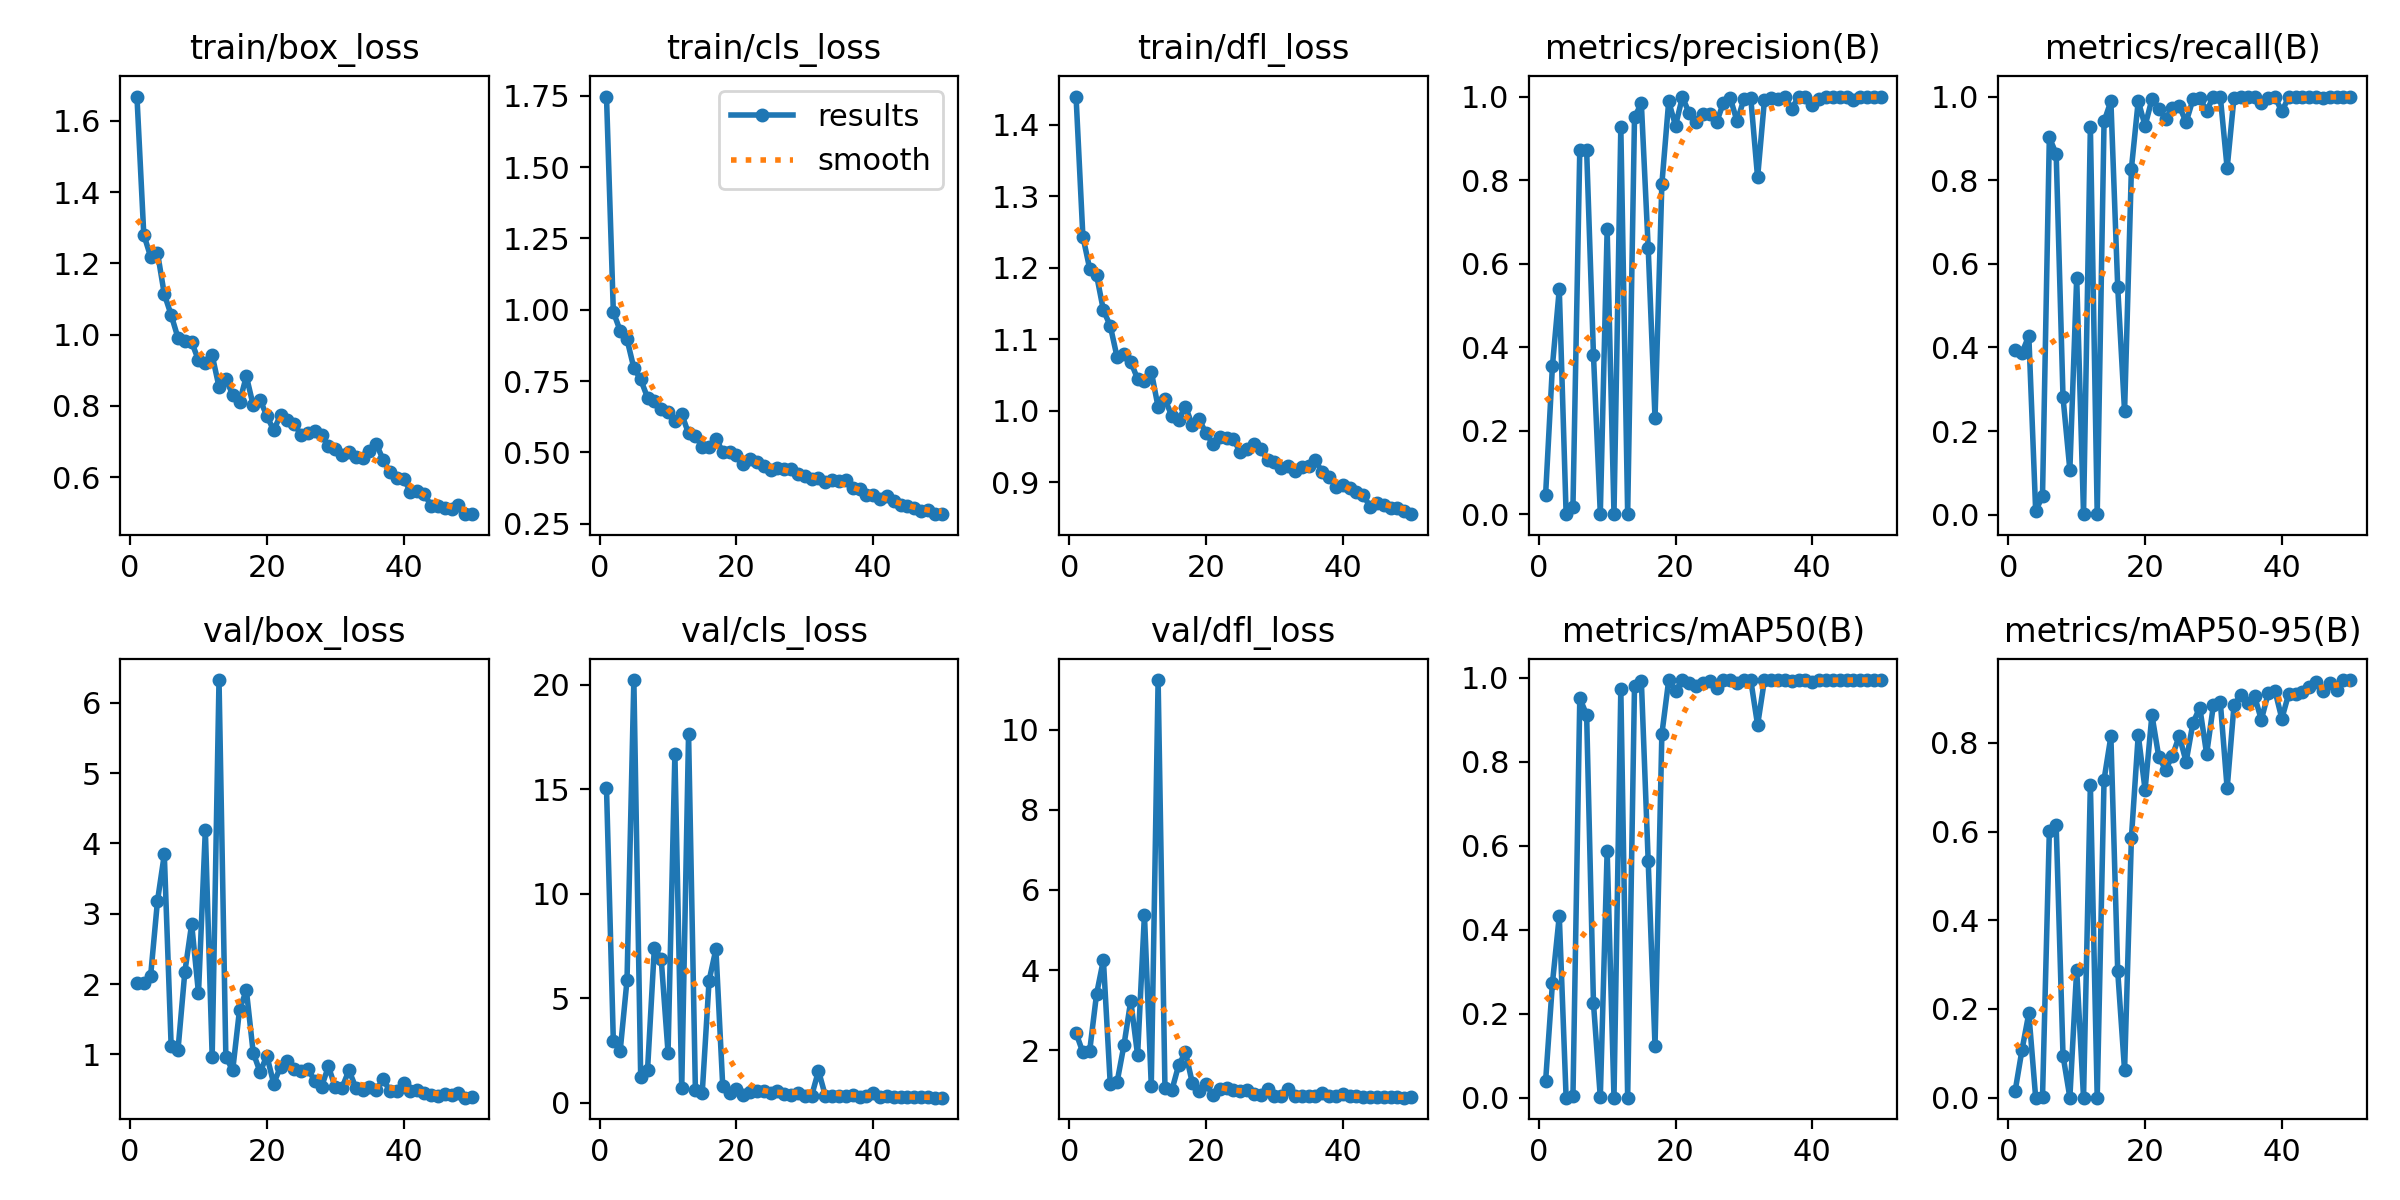


✓ Training results saved to Drive


In [8]:
from IPython.display import Image, display
import glob
import shutil

result_dirs = glob.glob('runs/detect/yolov8_microplastic/train_*')
if result_dirs:
    latest = sorted(result_dirs)[-1]
    results_img = f"{latest}/results.png"
    
    if os.path.exists(results_img):
        display(Image(results_img))
        
        # Save results to Drive
        training_results = [
            f"{latest}/results.png",
            f"{latest}/confusion_matrix.png",
            f"{latest}/F1_curve.png",
            f"{latest}/P_curve.png",
            f"{latest}/R_curve.png",
            f"{latest}/PR_curve.png"
        ]
        
        for result_file in training_results:
            if os.path.exists(result_file):
                filename = os.path.basename(result_file)
                shutil.copy(result_file, f'{drive_folder}/{filename}')
        
        print(f"\n✓ Training results saved to Drive")

## 8. Export Model to Drive

In [10]:
import shutil
import glob

model_files = glob.glob('runs/detect/yolov8_microplastic/*/weights/best.pt')
if model_files:
    best_model = model_files[0]
    drive_output = '/content/drive/MyDrive/microplastic_project/yolov8_microplastic_trained.pt'
    shutil.copy(best_model, drive_output)
    print(f"✓ Model saved: {drive_output}")

✓ Model saved: /content/drive/MyDrive/microplastic_project/yolov8_microplastic_trained.pt


## 9. Test Model

Test on 10 positive + 10 negative samples to evaluate performance.

In [11]:
from ultralytics import YOLO
import cv2
from pathlib import Path
import random
import time
import shutil
import subprocess

# Load model
model_files = glob.glob('runs/detect/yolov8_microplastic/*/weights/best.pt')
if not model_files:
    print("Error: Model not found")
else:
    model_path = model_files[0]
    model = YOLO(model_path)
    print(f"✓ Model loaded: {model_path}")
    
    # Find test images
    test_dir = Path('microplastic_data/test/images')
    labels_dir = Path('microplastic_data/test/labels')
    
    if test_dir.exists():
        all_images = list(test_dir.glob('*.jpg')) + list(test_dir.glob('*.bmp'))
        
        # Separate positive/negative samples
        positive_samples = []
        negative_samples = []
        
        for img_path in all_images:
            label_path = labels_dir / f"{img_path.stem}.txt"
            if label_path.exists():
                with open(label_path, 'r') as f:
                    if f.read().strip():
                        positive_samples.append(img_path)
                    else:
                        negative_samples.append(img_path)
            else:
                negative_samples.append(img_path)
        
        # Select 10+10 samples
        random.seed(42)
        selected_positive = random.sample(positive_samples, min(10, len(positive_samples)))
        selected_negative = random.sample(negative_samples, min(10, len(negative_samples)))
        test_images = selected_positive + selected_negative
        random.shuffle(test_images)
        
        # Create ground truth map
        ground_truth = {str(img): (img in selected_positive) for img in test_images}
        
        print(f"\nTesting {len(test_images)} images ({len(selected_positive)} positive, {len(selected_negative)} negative)\n")
        
        # Create output directory
        output_dir = Path('test_results')
        output_dir.mkdir(exist_ok=True)
        
        # Run detection
        tp, fp, tn, fn = 0, 0, 0, 0
        total_time = 0
        
        for i, img_path in enumerate(test_images, 1):
            is_positive = ground_truth[str(img_path)]
            label = "P" if is_positive else "N"
            
            start = time.time()
            results = model(str(img_path), conf=0.25, verbose=False)
            inference_time = (time.time() - start) * 1000
            total_time += inference_time
            
            num_detections = len(results[0].boxes)
            has_detection = num_detections > 0
            
            # Calculate metrics
            if is_positive and has_detection:
                tp += 1
                result = "✓ TP"
            elif is_positive and not has_detection:
                fn += 1
                result = "✗ FN"
            elif not is_positive and has_detection:
                fp += 1
                result = "✗ FP"
            else:
                tn += 1
                result = "✓ TN"
            
            print(f"[{i}/{len(test_images)}] {img_path.name} [{label}] {inference_time:.1f}ms | Det: {num_detections} | {result}")
            
            # Save annotated image
            annotated = results[0].plot()
            cv2.imwrite(str(output_dir / f"result_{i:02d}_{img_path.stem}.jpg"), annotated)
        
        # Calculate metrics
        accuracy = ((tp + tn) / len(test_images) * 100) if len(test_images) > 0 else 0
        precision = (tp / (tp + fp)) if (tp + fp) > 0 else 0
        recall = (tp / (tp + fn)) if (tp + fn) > 0 else 0
        avg_time = total_time / len(test_images)
        fps = 1000 / avg_time if avg_time > 0 else 0
        
        print(f"\n{'='*70}")
        print("Summary")
        print(f"TP: {tp} | FP: {fp} | TN: {tn} | FN: {fn}")
        print(f"Accuracy: {accuracy:.1f}% | Precision: {precision:.2f} | Recall: {recall:.2f}")
        print(f"Avg: {avg_time:.1f}ms | FPS: {fps:.1f}")
        print(f"{'='*70}")
        
        # Save summary
        with open(output_dir / 'test_summary.txt', 'w') as f:
            f.write("YOLOv8 Microplastic Detection Test Results\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"Test Images: {len(test_images)} ({len(selected_positive)} positive, {len(selected_negative)} negative)\n")
            f.write(f"Confidence: 0.25\n\n")
            f.write("Confusion Matrix:\n")
            f.write(f"  TP: {tp} | FP: {fp}\n")
            f.write(f"  TN: {tn} | FN: {fn}\n\n")
            f.write("Metrics:\n")
            f.write(f"  Accuracy:  {accuracy:.1f}%\n")
            f.write(f"  Precision: {precision:.2f}\n")
            f.write(f"  Recall:    {recall:.2f}\n\n")
            f.write("Performance:\n")
            f.write(f"  Avg: {avg_time:.1f}ms\n")
            f.write(f"  FPS: {fps:.1f}\n")
        
        # Save to Google Drive
        subprocess.run(['zip', '-qr', 'test_results.zip', 'test_results'], check=True)
        shutil.copy('test_results.zip', f'{drive_folder}/test_results.zip')
        print(f"\n✓ Results saved to Drive")
    else:
        print("Error: Test directory not found")

✓ Model loaded: runs/detect/yolov8_microplastic/train_20260308_183106/weights/best.pt

Testing 20 images (10 positive, 10 negative)

[1/20] microplastic_synthetic_00817.jpg [N] 800.6ms | Det: 0 | ✓ TN
[2/20] microplastic_synthetic_01500.jpg [N] 12.4ms | Det: 0 | ✓ TN
[3/20] microplastic_synthetic_01955.jpg [N] 10.9ms | Det: 0 | ✓ TN
[4/20] microplastic_synthetic_01672.jpg [P] 27.4ms | Det: 2 | ✓ TP
[5/20] microplastic_synthetic_00389.jpg [N] 12.5ms | Det: 0 | ✓ TN
[6/20] microplastic_synthetic_00656.jpg [P] 11.8ms | Det: 2 | ✓ TP
[7/20] microplastic_synthetic_01080.jpg [N] 12.0ms | Det: 0 | ✓ TN
[8/20] microplastic_synthetic_01591.jpg [P] 11.9ms | Det: 1 | ✓ TP
[9/20] microplastic_synthetic_01020.jpg [N] 11.4ms | Det: 0 | ✓ TN
[10/20] microplastic_synthetic_01476.jpg [P] 12.0ms | Det: 3 | ✓ TP
[11/20] microplastic_synthetic_01217.jpg [N] 11.4ms | Det: 0 | ✓ TN
[12/20] microplastic_synthetic_00921.jpg [P] 12.4ms | Det: 3 | ✓ TP
[13/20] microplastic_synthetic_01558.jpg [P] 12.4ms | Det: 